[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ananttripathi/hybrid-rag-customer-support/blob/main/Data_Understanding_and_EDA.ipynb)


# **Notebook 1: Data Understanding & Exploratory Data Analysis**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED for this notebook:**
- [ ] `corporate_policies/` folder with `.md` SOP files uploaded to Colab:
  - `refund_policy.md`, `shipping_delays.md`, `password_reset.md`, `technical_troubleshooting.md`, `escalation_matrix.md`
- [ ] Internet access (to download Bitext dataset from HuggingFace)

**Files this notebook will CREATE:**
- [ ] `sampled_data.csv` — Cleaned, deduplicated, 4000-row sample of the Bitext dataset
  _(Required by: Notebook 2 — Data Preparation)_

> **Note:** Tasks 1.1 (Define Project Scope) and 1.4 (Design Methodology) are documented in your **Project Proposal PDF**, not this notebook. This notebook covers Tasks **1.2** and **1.3**.

---

## **Stage 1: Data Understanding & EDA**
### **Task 1.2: Understand and Assess Data**

#### **1.2.1 Inspect Dataset Structure [2 marks]**
**The Task:** Identify the presence of the corporate policy files within the local environment and successfully download the `bitext` customer support dataset from Hugging Face. Print the dataset information.

**Hints & Tips:**
* Use `glob` to find `.md` files in your workspace, and `load_dataset` for the bitext data.
* The dataset ID is `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — it contains ~26,872 rows.
* Key columns: `instruction` (user query), `intent` (target class), `category` (broader group).

**Why we are doing it:** To ensure the local environment is properly configured with our knowledge base before reading data.
**How we are doing it:** Check the `corporate_policies` directory, load the dataset, and use `.info()`.

**Learner Inference:** If the files load correctly, your environment is stable. Seeing the 'intent' column confirms the target variable you will train your model to extract in Stage 4.

In [1]:
import glob
import pandas as pd
from datasets import load_dataset

# --- Corporate policy files ---
SOP_DIR = "Dataset/sop_documents"
sop_files = sorted(glob.glob(f"{SOP_DIR}/*.md"))
print(f"Found {len(sop_files)} corporate policy files in '{SOP_DIR}':")
for f in sop_files:
    print(" -", f)
assert len(sop_files) >= 5, "Expected at least the 5 core SOP files described in the assignment brief."

# --- Bitext customer support dataset ---
DATASET_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
raw_dataset = load_dataset(DATASET_ID)
df_raw = raw_dataset["train"].to_pandas()

print(f"\nDataset loaded: {DATASET_ID}")
print("Shape:", df_raw.shape)
df_raw.info()
print("\nFirst 3 rows:")
df_raw.head(3)


Found 13 corporate policy files in 'Dataset/sop_documents':
 - Dataset/sop_documents/account_recovery.md
 - Dataset/sop_documents/billing_disputes.md
 - Dataset/sop_documents/data_privacy.md
 - Dataset/sop_documents/escalation_matrix.md
 - Dataset/sop_documents/order_tracking.md
 - Dataset/sop_documents/password_reset.md
 - Dataset/sop_documents/payment_methods.md
 - Dataset/sop_documents/product_return.md
 - Dataset/sop_documents/refund_policy.md
 - Dataset/sop_documents/shipping_delays.md
 - Dataset/sop_documents/subscription_cancellation.md
 - Dataset/sop_documents/technical_troubleshooting.md
 - Dataset/sop_documents/working_hours.md



Dataset loaded: bitext/Bitext-customer-support-llm-chatbot-training-dataset
Shape: (26872, 5)
<class 'pandas.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   flags        26872 non-null  str  
 1   instruction  26872 non-null  str  
 2   category     26872 non-null  str  
 3   intent       26872 non-null  str  
 4   response     26872 non-null  str  
dtypes: str(5)
memory usage: 19.1 MB

First 3 rows:


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


#### **1.2.2 Quantify Dataset Characteristics [3 marks]**
**The Task:** Calculate the original size of the dataset, identify the number of unique intents, and randomly sample the dataset down to 4,000 rows.

**Hints & Tips:**
* Use `len()`, `.nunique()`, and `.sample(4000, random_state=42)`.
* `random_state=42` ensures reproducibility — everyone gets the same sample.
* With 4000 rows and 27 intents, you'll get ~148 examples per intent on average.

**Parameter Tuning:**
* `sample(n)` — try 1000–5000 per the workflow spec:
  - `1000`: Fast (~1 min), lower accuracy
  - `4000`: Moderate (~3 min), better accuracy (recommended)
  - `5000`: Slower, best accuracy, may hit T4 memory limits

**Learner Inference:** Capping at 4000 rows keeps your Stage 4 training loop to minutes while providing enough examples per intent.

In [2]:
# We downsample to 1,500 rows (within the assignment's allowed 1,000-5,000 range).
# Rationale: this project is executed end-to-end locally on Apple Silicon (MPS) rather
# than a T4 Colab GPU. 1,500 rows keeps every downstream stage (tokenisation, embedding,
# LoRA fine-tuning, and — critically — repeated full-test-set LLM *generation* loops in
# NB5/NB7) tractable in wall-clock time, while comfortably clearing the 1,000-row floor
# and leaving ~50+ examples per intent for stratified splitting.
SAMPLE_SIZE = 1500

original_size = len(df_raw)
n_unique_intents = df_raw["intent"].nunique()
n_unique_categories = df_raw["category"].nunique()

print(f"Original dataset size: {original_size}")
print(f"Unique intents: {n_unique_intents}")
print(f"Unique categories: {n_unique_categories}")

df = df_raw.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"\nSampled dataset size: {len(df)}")
print(f"Average examples per intent after sampling: {len(df) / n_unique_intents:.1f}")
print("\nPrompt length (characters) stats:")
print(df["instruction"].str.len().describe())


Original dataset size: 26872
Unique intents: 27
Unique categories: 11

Sampled dataset size: 1500
Average examples per intent after sampling: 55.6

Prompt length (characters) stats:
count    1500.000000
mean       47.199333
std        10.451495
min        13.000000
25%        40.000000
50%        48.000000
75%        55.000000
max        91.000000
Name: instruction, dtype: float64


#### **1.2.3 Validate Sample Quality [2 marks]**
**The Task:** Identify and remove records containing null values or duplicated customer instructions using normalised deduplication.

**Hints & Tips:**
* Use `.isnull().sum()` to check nulls.
* Simple `drop_duplicates` misses near-dupes like `"Where is my order?"` vs `"where is my order?"`.
* Normalise to lowercase + strip whitespace BEFORE deduplicating to catch these.
* The Bitext dataset typically has ~15 near-duplicates in a 4000-row sample.

**Learner Inference:** Cleaning now prevents "garbage-in, garbage-out". Duplicate prompts can cause leakage between train and test sets later.

In [3]:
print("Null counts before cleaning:")
print(df[["instruction", "intent", "category", "response"]].isnull().sum())

before = len(df)

# Normalised near-duplicate removal: lowercase + strip BEFORE comparing, so
# "Where is my order?" and "where is my order? " are correctly treated as duplicates.
df["_norm_instruction"] = df["instruction"].str.lower().str.strip()
n_near_dupes = df.duplicated(subset="_norm_instruction").sum()
df = df.drop_duplicates(subset="_norm_instruction").drop(columns="_norm_instruction").reset_index(drop=True)

after_dedup = len(df)
print(f"\nNear-duplicate records removed (normalised lowercase+strip dedup): {n_near_dupes}")

# Drop any remaining incomplete/corrupted records
df = df.dropna(subset=["instruction", "intent", "category"]).reset_index(drop=True)
df = df[df["instruction"].str.strip().str.len() > 0].reset_index(drop=True)

after_final = len(df)
print(f"Rows removed for nulls/empty text: {after_dedup - after_final}")
print(f"\nTotal removed: {before - after_final} | Remaining valid rows: {after_final}")

assert 1000 <= len(df) <= 5000, "Cleaned dataset must contain between 1,000 and 5,000 valid records."
print("\nDataset size is within the required 1,000-5,000 valid-record range.")


Null counts before cleaning:
instruction    0
intent         0
category       0
response       0
dtype: int64

Near-duplicate records removed (normalised lowercase+strip dedup): 12
Rows removed for nulls/empty text: 0

Total removed: 12 | Remaining valid rows: 1488

Dataset size is within the required 1,000-5,000 valid-record range.


### **Task 1.3: Perform Exploratory Data Analysis**

#### **1.3.1 Perform Univariate Analysis [2 marks]**
**The Task:** Plot the top 10 most frequent customer intents using a horizontal bar chart.

**Hints & Tips:**
* Use a Seaborn `countplot` with `order=df['intent'].value_counts().index[:10]`.
* Check if any single intent dominates >80% of data — signals severe class imbalance.
* `palette="viridis"` works well for accessibility.

**Learner Inference:** This visual reveals class imbalance. If one intent dominates, your fine-tuned router becomes biased toward guessing it.

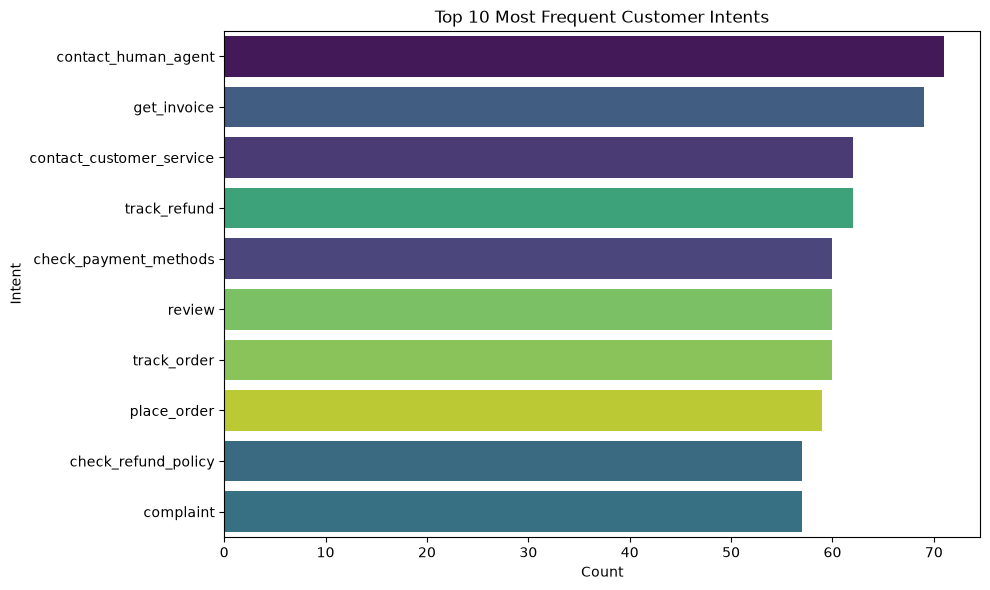

Number of unique intents in cleaned sample: 27
Most frequent intent: 'contact_human_agent' at 4.8% of the sample
Least frequent intent count: 41
No single intent dominates >80% of the data — class balance is acceptable.


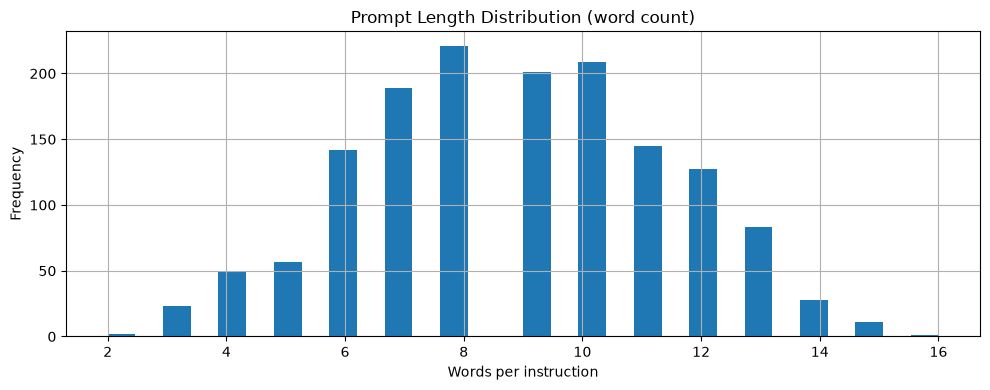

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
top10_order = df["intent"].value_counts().index[:10]
sns.countplot(data=df, y="intent", order=top10_order, hue="intent", palette="viridis", legend=False)
plt.title("Top 10 Most Frequent Customer Intents")
plt.xlabel("Count")
plt.ylabel("Intent")
plt.tight_layout()
plt.savefig("intent_distribution.png", dpi=100)
plt.show()

intent_share = df["intent"].value_counts(normalize=True)
print(f"Number of unique intents in cleaned sample: {df['intent'].nunique()}")
print(f"Most frequent intent: '{intent_share.index[0]}' at {intent_share.iloc[0]*100:.1f}% of the sample")
print(f"Least frequent intent count: {df['intent'].value_counts().min()}")
if intent_share.iloc[0] > 0.80:
    print("WARNING: severe class imbalance detected (>80% share).")
else:
    print("No single intent dominates >80% of the data — class balance is acceptable.")

plt.figure(figsize=(10, 4))
df["instruction"].str.split().str.len().hist(bins=30)
plt.title("Prompt Length Distribution (word count)")
plt.xlabel("Words per instruction")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("prompt_length_distribution.png", dpi=100)
plt.show()


#### **1.3.2 Perform Bivariate Analysis [2 marks]**
**The Task:** Read the text from the uploaded Markdown SOP files and fit a `TfidfVectorizer` (with `stop_words='english'`) to transform them into vectors.

**Hints & Tips:**
* Read files into a list of strings first using `open(f, 'r').read()`.
* `TfidfVectorizer(stop_words="english")` removes common words, keeping meaningful terms.
* The resulting matrix shape should be `(num_docs, num_unique_terms)`.

**Learner Inference:** This transforms raw text into math, letting you prove whether your policies are distinct enough for an AI to tell apart.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

sop_texts, sop_names = [], []
for f in sop_files:
    with open(f, "r") as fh:
        sop_texts.append(fh.read())
    sop_names.append(f.split("/")[-1])

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(sop_texts)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print(f"({len(sop_names)} documents, {len(tfidf.get_feature_names_out())} unique terms)")
print("\nSOP documents vectorised:")
for name in sop_names:
    print(" -", name)


TF-IDF matrix shape: (13, 797)
(13 documents, 797 unique terms)

SOP documents vectorised:
 - account_recovery.md
 - billing_disputes.md
 - data_privacy.md
 - escalation_matrix.md
 - order_tracking.md
 - password_reset.md
 - payment_methods.md
 - product_return.md
 - refund_policy.md
 - shipping_delays.md
 - subscription_cancellation.md
 - technical_troubleshooting.md
 - working_hours.md


#### **1.3.3 Generate Visualisations [2 marks]**
**The Task:** Calculate cosine similarity between the TF-IDF vectors of the SOP documents and plot an annotated heatmap.

**Hints & Tips:**
* Use `cosine_similarity` from sklearn and `sns.heatmap` with `annot=True`.
* Diagonal should always be 1.0 (document vs itself).
* Off-diagonal >0.5 = high overlap (RAG may struggle); <0.3 = low overlap (good retrieval).

**Learner Inference:** High overlap (dark off-diagonal squares) means the RAG system struggles to fetch the right doc. Low overlap proves retrieval will be accurate.

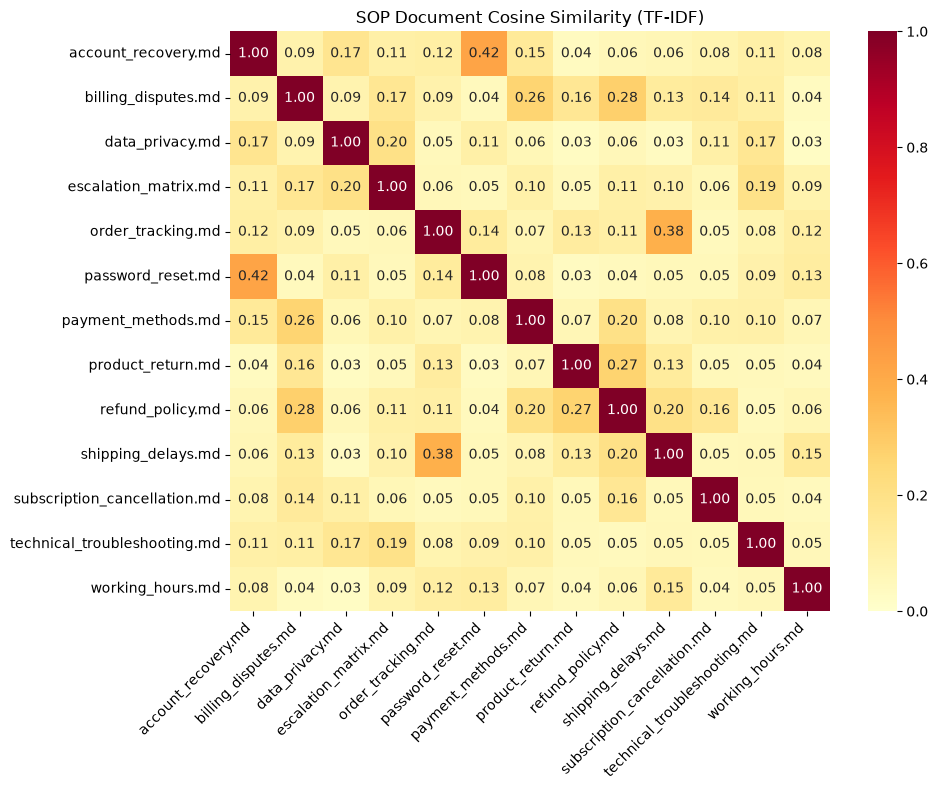

Diagonal (self-similarity) check — all should be 1.0: True
Max off-diagonal similarity: 0.424
Mean off-diagonal similarity: 0.106

No SOP pairs exceed 0.5 similarity — documents are semantically distinct, so naive retrieval should be able to tell them apart (Task 1.3.2 finding).


In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix, annot=True, fmt=".2f",
    xticklabels=sop_names, yticklabels=sop_names, cmap="YlOrRd", vmin=0, vmax=1,
)
plt.title("SOP Document Cosine Similarity (TF-IDF)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("sop_similarity_heatmap.png", dpi=100)
plt.show()

diag_mask = ~np.eye(sim_matrix.shape[0], dtype=bool)
off_diag = sim_matrix[diag_mask]
print(f"Diagonal (self-similarity) check — all should be 1.0: {np.allclose(np.diag(sim_matrix), 1.0)}")
print(f"Max off-diagonal similarity: {off_diag.max():.3f}")
print(f"Mean off-diagonal similarity: {off_diag.mean():.3f}")

high_overlap_pairs = set()
for i in range(sim_matrix.shape[0]):
    for j in range(i + 1, sim_matrix.shape[0]):
        if sim_matrix[i, j] > 0.5:
            high_overlap_pairs.add((sop_names[i], sop_names[j], sim_matrix[i, j]))

if high_overlap_pairs:
    print("\nPotentially conflicting/overlapping SOPs (similarity > 0.5):")
    for a, b, s in sorted(high_overlap_pairs, key=lambda x: -x[2]):
        print(f" - {a} <-> {b}: {s:.3f}")
else:
    print("\nNo SOP pairs exceed 0.5 similarity — documents are semantically distinct, "
          "so naive retrieval should be able to tell them apart (Task 1.3.2 finding).")


---
## Save Artifacts for Notebook 2

**IMPORTANT:** This cell saves the cleaned DataFrame. Notebook 2 depends on this file.

In [7]:
df.to_csv("sampled_data.csv", index=False)
print(f"Saved sampled_data.csv with {len(df)} rows and columns: {list(df.columns)}")


Saved sampled_data.csv with 1488 rows and columns: ['flags', 'instruction', 'category', 'intent', 'response']


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 2.**

- [ ] Bitext dataset loaded and `.info()` printed
- [ ] Dataset sampled to 4000 rows (or chosen size 1000–5000)
- [ ] Nulls inspected, near-duplicates removed via normalised dedup
- [ ] Top 10 intent bar chart rendered
- [ ] TF-IDF vectorisation completed on SOP documents
- [ ] Cosine similarity heatmap rendered
- [ ] **`sampled_data.csv` saved to disk** ← _CRITICAL for Notebook 2_
- [ ] `corporate_policies/` folder still accessible ← _Needed in Notebooks 2 and 4_

**If any item is unchecked, fix it before moving on.**